# CSCI E-89 Deep Learning — Assignment 03, Problem 3

* **Name:** Levente Papp
* **Course:** CSCI E-89 Deep Learning, Harvard Extension School
* **Assignment:** Assignment 03, Problem 3

This notebook rebuilds the *Building an Image Classifier with PyTorch* pipeline
from Aurélien Géron's chapter 10 notebook (`10_neural_nets_with_pytorch.ipynb`)
in a single Claude Code session. It trains a multilayer perceptron on
Fashion MNIST and adds a plot of training and validation accuracy.

Each code cell below is one standalone script from the `prob3/` folder of the
repository, in execution order. The only change from the scripts is that their
short "standalone bootstrap" block is removed: in the scripts it runs the earlier
steps when a script is launched on its own, which a notebook doesn't need.

## Step 1: `prob3/01_setup.py`

Imports PyTorch, torchvision, torchmetrics, Matplotlib and NumPy, fixes the
random seed (42) for Python, NumPy and PyTorch so results are reproducible, and
picks the device: a CUDA GPU if present, else an Apple Silicon (MPS) GPU, else
the CPU.

In [1]:
# CSCI E-89 Assignment 03, Problem 3 -- Step 1: setup
# Author: Levente Papp
# Imports, random seeds, and device selection (CUDA, MPS, or CPU).

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader

# Fix every random number generator so that runs are reproducible
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Pick the fastest available device: NVIDIA GPU, Apple Silicon GPU, else CPU
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

# Folder that holds this pipeline (prob3/). A notebook has no __file__, so it
# falls back to the working directory, which is the notebook's own folder.
BASE_DIR = (Path(__file__).resolve().parent if "__file__" in globals()
            else Path.cwd())
FIGURES_DIR = BASE_DIR / "figures"  # where the scripts save their plots
FIGURES_DIR.mkdir(exist_ok=True)

print(f"PyTorch {torch.__version__}, torchvision {torchvision.__version__}, "
      f"torchmetrics {torchmetrics.__version__}")
print(f"Random seed: {SEED}")
print(f"Using device: {device}")

PyTorch 2.14.0+cu130, torchvision 0.29.0+cu130, torchmetrics 1.9.0
Random seed: 42
Using device: cpu


## Step 2: `prob3/02_load_data.py`

Downloads Fashion MNIST with torchvision and converts each image to a
`float32` tensor scaled to [0, 1]. The 60,000 training images are split
randomly into 55,000 for training and 5,000 for validation; the 10,000 test
images are kept separate. Each set is wrapped in a `DataLoader` with batch
size 32 (only the training loader shuffles). The cell prints the dataset sizes
and the shape of one batch: `[32, 1, 28, 28]` = batch, channel, rows, columns.

In [2]:
# CSCI E-89 Assignment 03, Problem 3 -- Step 2: load Fashion MNIST
# Author: Levente Papp
# Convert each PIL image to a tensor, then to float32 scaled from [0, 255]
# to [0, 1]
toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

# Download (first run only) the 60,000 training and 10,000 test images
DATA_DIR = BASE_DIR / "datasets"
train_and_valid_data = torchvision.datasets.FashionMNIST(
    root=DATA_DIR, train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root=DATA_DIR, train=False, download=True, transform=toTensor)
class_names = train_and_valid_data.classes  # e.g. "T-shirt/top", "Trouser"

# Randomly split the 60,000 training images into 55,000 train + 5,000 valid
torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

# Batch the data; only the training set is shuffled (reshuffled every epoch)
torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

print(f"Training set:   {len(train_data):,} images")
print(f"Validation set: {len(valid_data):,} images")
print(f"Test set:       {len(test_data):,} images")

# One batch: images are [batch, channels, rows, columns], labels are [batch]
X_batch, y_batch = next(iter(train_loader))
print(f"One batch of images: {tuple(X_batch.shape)}, dtype {X_batch.dtype}, "
      f"values in [{X_batch.min():.1f}, {X_batch.max():.1f}]")
print(f"One batch of labels: {tuple(y_batch.shape)}, dtype {y_batch.dtype}")

Training set:   55,000 images
Validation set: 5,000 images
Test set:       10,000 images
One batch of images: (32, 1, 28, 28), dtype torch.float32, values in [0.0, 1.0]
One batch of labels: (32,), dtype torch.int64


## Step 3: `prob3/03_show_samples.py`

Shows a 4 × 8 grid of the first 32 training images with their class names, as
a quick check that images and labels line up.

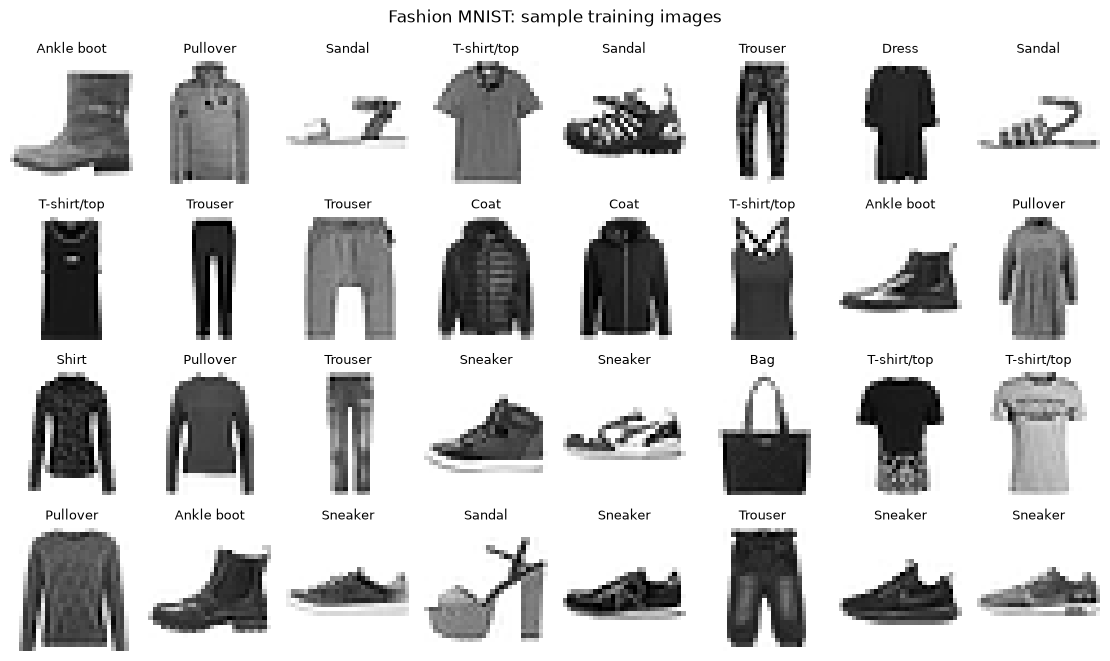

In [3]:
# CSCI E-89 Assignment 03, Problem 3 -- Step 3: show sample training images
# Author: Levente Papp
n_rows, n_cols = 4, 8
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.4, n_rows * 1.7))
for index, ax in enumerate(axes.flat):
    image, label = train_data[index]      # image: [1, 28, 28], label: int
    ax.imshow(image.squeeze(0), cmap="binary")  # drop the channel dimension
    ax.set_title(class_names[label], fontsize=9)
    ax.axis("off")
fig.suptitle("Fashion MNIST: sample training images")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "samples.png", dpi=100)
plt.show()

## Step 4: `prob3/04_helpers.py`

Defines two helpers:

* `evaluate_tm()` runs the model over a `DataLoader` in evaluation mode without
  gradients and returns a torchmetrics metric (here, accuracy).
* `train()` trains for `n_epochs`. For each batch it does the forward pass,
  computes the loss, backpropagates, and takes an optimizer step. After each
  epoch it records the mean training loss, the training accuracy and the
  validation accuracy in a `history` dict, and prints them.

In [4]:
# CSCI E-89 Assignment 03, Problem 3 -- Step 4: evaluation and training helpers
# Author: Levente Papp
def evaluate_tm(model, data_loader, metric):
    """Compute a torchmetrics metric for `model` over a whole DataLoader."""
    model.eval()     # evaluation mode (matters for dropout, batch norm, ...)
    metric.reset()   # forget results from any previous call
    with torch.no_grad():  # no gradients needed: faster, uses less memory
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)  # accumulate batch statistics
    return metric.compute()  # combine the batches into one value


def train(model, optimizer, criterion, metric, train_loader, valid_loader,
          n_epochs):
    """Train for n_epochs; return a history dict of per-epoch results."""
    history = {"train_loss": [], "train_accuracy": [], "valid_accuracy": []}
    for epoch in range(n_epochs):
        model.train()  # training mode (evaluate_tm switched to eval mode)
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)            # forward pass: logits
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()                    # backprop: compute gradients
            optimizer.step()                   # gradient descent step
            optimizer.zero_grad()              # reset gradients for next batch
            metric.update(y_pred, y_batch)     # running training accuracy
        history["train_loss"].append(total_loss / len(train_loader))
        history["train_accuracy"].append(metric.compute().item())
        history["valid_accuracy"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1:2d}/{n_epochs}, "
              f"train loss: {history['train_loss'][-1]:.4f}, "
              f"train accuracy: {history['train_accuracy'][-1]:.4f}, "
              f"valid accuracy: {history['valid_accuracy'][-1]:.4f}")
    return history


print("Defined evaluate_tm() and train()")

Defined evaluate_tm() and train()


## Step 5: `prob3/05_model.py`

Defines `ImageClassifier`, a multilayer perceptron: `Flatten` (28 × 28 → 784),
a hidden layer of 300 ReLU units, one of 100 ReLU units, and 10 output logits,
one per class. The cell also creates the cross-entropy loss, an SGD optimizer
with learning rate 0.1, and a 10-class accuracy metric, then prints the model
and its parameter count:
784·300+300 + 300·100+100 + 100·10+10 = 266,610.

In [5]:
# CSCI E-89 Assignment 03, Problem 3 -- Step 5: model, loss, optimizer, metric
# Author: Levente Papp
class ImageClassifier(nn.Module):
    """MLP: 28x28 image -> 300 -> 100 -> 10 class logits."""
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),                    # [batch, 1, 28, 28] -> [batch, 784]
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)  # logits, no softmax (the loss does it)
        )

    def forward(self, X):
        return self.mlp(X)


torch.manual_seed(42)  # reproducible initial weights
model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300, n_hidden2=100,
                        n_classes=10).to(device)
xentropy = nn.CrossEntropyLoss()  # applies log-softmax to the logits itself
# Create the optimizer after moving the model to the device
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

print(model)
n_params = sum(param.numel() for param in model.parameters())
print(f"Number of parameters: {n_params:,}")

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)
Number of parameters: 266,610


## Step 6: `prob3/06_train.py`

Trains the model for `n_epochs = 20` and keeps the per-epoch results in
`history`. This takes about 3 minutes on a CPU.

In [6]:
# CSCI E-89 Assignment 03, Problem 3 -- Step 6: train the model
# Author: Levente Papp
n_epochs = 20
# history holds per-epoch train_loss, train_accuracy and valid_accuracy
history = train(model, optimizer, xentropy, accuracy, train_loader,
                valid_loader, n_epochs)

Epoch  1/20, train loss: 0.6060, train accuracy: 0.7814, valid accuracy: 0.8424


Epoch  2/20, train loss: 0.4061, train accuracy: 0.8496, valid accuracy: 0.8402


Epoch  3/20, train loss: 0.3630, train accuracy: 0.8661, valid accuracy: 0.8494


Epoch  4/20, train loss: 0.3355, train accuracy: 0.8768, valid accuracy: 0.8638


Epoch  5/20, train loss: 0.3154, train accuracy: 0.8829, valid accuracy: 0.8782


...

Epoch 16/20, train loss: 0.2078, train accuracy: 0.9196, valid accuracy: 0.8886


Epoch 17/20, train loss: 0.2033, train accuracy: 0.9233, valid accuracy: 0.8870


Epoch 18/20, train loss: 0.1991, train accuracy: 0.9230, valid accuracy: 0.8846


Epoch 19/20, train loss: 0.1916, train accuracy: 0.9266, valid accuracy: 0.8812


Epoch 20/20, train loss: 0.1876, train accuracy: 0.9286, valid accuracy: 0.8788


## Step 7: `prob3/07_plot_accuracy.py`

Plots training and validation accuracy per epoch on the same chart. Training
accuracy is averaged over each epoch while the weights are still changing, so
it is drawn half an epoch to the left, as in Géron's notebook. The gap between
the curves (training above validation) shows the model starting to overfit.

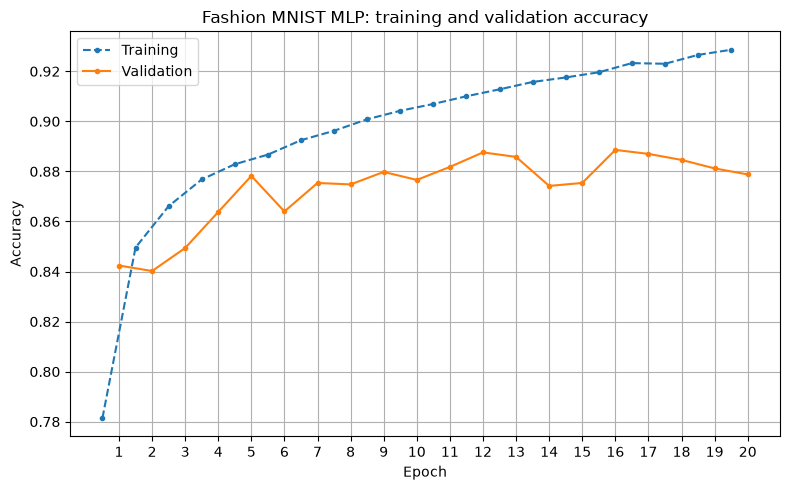

In [7]:
# CSCI E-89 Assignment 03, Problem 3 -- Step 7: plot the accuracy curves
# Author: Levente Papp
epochs = np.arange(1, n_epochs + 1)
fig, ax = plt.subplots(figsize=(8, 5))
# Training accuracy is averaged over each epoch while the model is still
# learning, so (as in Geron's notebook) it is plotted half an epoch earlier;
# validation accuracy is measured at the end of each epoch.
ax.plot(epochs - 0.5, history["train_accuracy"], ".--", label="Training")
ax.plot(epochs, history["valid_accuracy"], ".-", label="Validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Fashion MNIST MLP: training and validation accuracy")
ax.set_xticks(epochs)
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "accuracy.png", dpi=100)
plt.show()

## Step 8: `prob3/08_evaluate.py`

Reports the final training and validation accuracy and the accuracy on the
test set. Then, for the first 3 validation images, it prints the predicted and
true classes, the softmax probabilities for all 10 classes, and the top-4
predictions with their probabilities (renormalized over those 4 classes, as in
Géron's notebook).

In [8]:
# CSCI E-89 Assignment 03, Problem 3 -- Step 8: test accuracy and predictions
# Author: Levente Papp
# Accuracy on the 10,000 test images, which the model has never seen
test_accuracy = evaluate_tm(model, test_loader, accuracy).item()
print(f"Final training accuracy:   {history['train_accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history['valid_accuracy'][-1]:.4f}")
print(f"Test accuracy:             {test_accuracy:.4f}")

# Predict the first 3 validation images
model.eval()
X_new, y_new = next(iter(valid_loader))
X_new, y_new = X_new[:3].to(device), y_new[:3]
with torch.no_grad():
    y_pred_logits = model(X_new)
y_pred = y_pred_logits.argmax(dim=1).cpu()  # index of the largest logit

print(f"\nPredicted class indices: {y_pred.tolist()}")
print(f"Predicted classes: {[class_names[i] for i in y_pred]}")
print(f"True class indices:      {y_new.tolist()}")
print(f"True classes:      {[class_names[i] for i in y_new]}")

# Softmax turns the logits into class probabilities (each row sums to 1)
y_proba = F.softmax(y_pred_logits, dim=1).cpu()
print("\nClass probabilities (one row per image, one column per class):")
print(y_proba.round(decimals=3))

# The 4 most likely classes per image, with probabilities renormalized over
# those 4 classes (as in Geron's notebook)
y_top4_values, y_top4_indices = torch.topk(y_pred_logits, k=4, dim=1)
y_top4_probas = F.softmax(y_top4_values, dim=1).cpu()
y_top4_indices = y_top4_indices.cpu()
print("\nTop-4 predictions:")
for i in range(len(X_new)):
    top4 = ", ".join(f"{class_names[c]} ({p:.3f})"
                     for c, p in zip(y_top4_indices[i], y_top4_probas[i]))
    print(f"  Image {i} (true: {class_names[y_new[i]]}): {top4}")

Final training accuracy:   0.9286
Final validation accuracy: 0.8788
Test accuracy:             0.8824

Predicted class indices: [7, 4, 2]
Predicted classes: ['Sneaker', 'Coat', 'Pullover']
True class indices:      [7, 4, 2]
True classes:      ['Sneaker', 'Coat', 'Pullover']

Class probabilities (one row per image, one column per class):
tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.8590, 0.0000,
         0.1410],
        [0.0000, 0.0000, 0.0070, 0.0000, 0.9930, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0040, 0.0000, 0.5920, 0.0000, 0.2120, 0.0000, 0.1910, 0.0000, 0.0010,
         0.0000]])

Top-4 predictions:
  Image 0 (true: Sneaker): Sneaker (0.859), Ankle boot (0.141), Sandal (0.000), Trouser (0.000)
  Image 1 (true: Coat): Coat (0.993), Pullover (0.007), Shirt (0.000), Bag (0.000)
  Image 2 (true: Pullover): Pullover (0.593), Coat (0.212), Shirt (0.192), T-shirt/top (0.004)
